In [4]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage, RemoveMessage
from langgraph.checkpoint.memory  import InMemorySaver

In [5]:
class State(MessagesState):
    summary:str

In [6]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=100,
    temperature=0,
    seed=42
)

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [7]:
def ask(state=State)-> State:
    print("*"*10)
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(input())])    

In [8]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    system_message = f'''
    Here is the Quick Summary of what has been discussed so far:
    {state.get("summary","")}

    Keep this in mind as you answer the next question.
    '''
    response = chat.invoke([SystemMessage(system_message)]+state["messages"])
    response.pretty_print()
    return State(messages = [response])

In [9]:
def summarise_messages(state:State) -> State:
    print(f"----------> Entering summarise_and_delete_messages:")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f"""
update the ongoing summary by incorporating the new lines of conversation below.
Build upon the previous summary rather than repeating it so that the result reflects
the most recent context and developments.

Previous Summary:
{state.get("summary","")}

New Conversation:
{new_conversation}
"""

    print(summary_instructions)
    summary = chat.invoke([HumanMessage(summary_instructions)])

    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:-5]]
    return State(messages=remove_messages, summary=summary.content)

In [10]:
graph = StateGraph(State)

graph.add_node("ask", ask)
graph.add_node("chatbot", chatbot)
graph.add_node("summarise_messages", summarise_messages)

In [11]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "summarise_messages")
graph.add_edge("summarise_messages", END)

In [12]:
checkpointer = InMemorySaver()
graph_compiled = graph.compile(checkpointer)

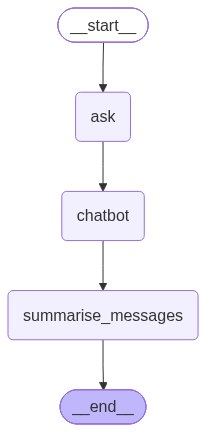

In [13]:
graph_compiled

In [14]:
config1 = {"configurable" : {"thread_id":"1"}}

In [20]:
graph_states = graph_compiled.invoke(State(),config1)

**********

-------> Entering the ask state
================================ Human Message =================================

who is the CM of west bengal?
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User asks: "who is the CM of west bengal?"
   - This is a straightforward factual question about the current Chief Minister of West Bengal, India.

2.  **Identify Key Information Needed:**
   - Current Chief Minister of West Bengal
   - Need to verify the most up-to-date information (as of 2024/2025)
   - Historical context: Mamata Banerjee has been the CM since 2011, and she won the 2021 West Bengal Legislative Assembly election, continuing her tenure.

3.  **Check Knowledge Cutoff & Current Date:**
   - My knowledge cutoff is 2026.
   - As of 2024/2025/2026, Mamata Banerjee is still the Chief Minister of West Bengal. There have been no major changes reported up to my training data.

In [16]:
graph_states

{'messages': [AIMessage(content='What is your Question ?', additional_kwargs={}, response_metadata={}, id='5d0be911-c8a6-467c-bd44-61a4cb620e5b', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='who is the CM of west bengal?', additional_kwargs={}, response_metadata={}, id='c2e61f97-fd52-402f-becd-9cc51997620d'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User asks: "who is the CM of west bengal?"\n   - This is a straightforward factual question about the current Chief Minister of West Bengal, India.\n\n2.  **Identify Key Information Needed:**\n   - Current Chief Minister of West Bengal\n   - Need to verify the most up-to-date information (as of 2024/2025)\n   - Historical context: Mamata Banerjee has been the CM since 2011, and she won the 2021 West Bengal Legislative Assembly election, continuing her tenure.\n\n3.  **Check Knowledge Cutoff & Current Date:**\n   - My knowledge cutoff is 2026.\n   - As of 2024/2025/202

In [17]:
graph_states = [i for i in graph_compiled.get_state_history(config1)]

In [18]:
graph_states

[StateSnapshot(values={'messages': [AIMessage(content='What is your Question ?', additional_kwargs={}, response_metadata={}, id='5d0be911-c8a6-467c-bd44-61a4cb620e5b', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='who is the CM of west bengal?', additional_kwargs={}, response_metadata={}, id='c2e61f97-fd52-402f-becd-9cc51997620d'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User asks: "who is the CM of west bengal?"\n   - This is a straightforward factual question about the current Chief Minister of West Bengal, India.\n\n2.  **Identify Key Information Needed:**\n   - Current Chief Minister of West Bengal\n   - Need to verify the most up-to-date information (as of 2024/2025)\n   - Historical context: Mamata Banerjee has been the CM since 2011, and she won the 2021 West Bengal Legislative Assembly election, continuing her tenure.\n\n3.  **Check Knowledge Cutoff & Current Date:**\n   - My knowledge cutoff is 2026.\n   - A